
--> Resultat x(t) per c = 2 <--
---------------------------------
 ⎛        10.0⋅t                                                               ↪
-⎝- 0.25⋅ℯ       + 0.322748612183951⋅sinh(7.74596669241483⋅t) + 0.25⋅cosh(7.74 ↪

↪                ⎞  -10.0⋅t     
↪ 596669241483⋅t)⎠⋅ℯ       ⋅θ(t)


--> Resultat x(t) per c = 4 <--
---------------------------------
 ⎛        20.0⋅t                                                               ↪
-⎝- 0.25⋅ℯ       + 0.263523138347365⋅sinh(18.9736659610103⋅t) + 0.25⋅cosh(18.9 ↪

↪                ⎞  -20.0⋅t     
↪ 736659610103⋅t)⎠⋅ℯ       ⋅θ(t)


--> Resultat x(t) per c = 5 <--
---------------------------------
 ⎛        25.0⋅t                                                               ↪
-⎝- 0.25⋅ℯ       + 0.258405697060851⋅sinh(24.1867732448956⋅t) + 0.25⋅cosh(24.1 ↪

↪                ⎞  -25.0⋅t     
↪ 867732448956⋅t)⎠⋅ℯ       ⋅θ(t)



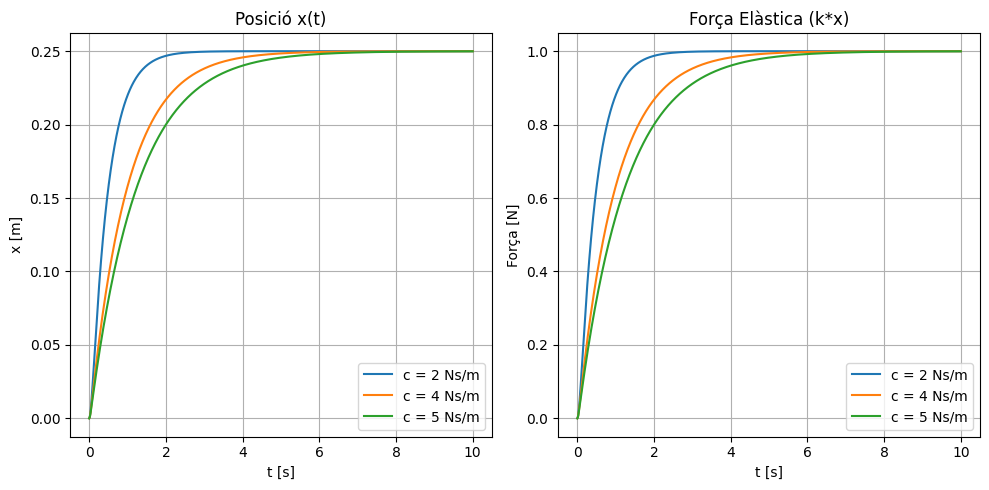

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# 1. Definició de variables simbòliques
s, t = sp.symbols('s t', real=True)

# Paràmetres del sistema
m = 0.1          # massa (kg)
c_values = [2, 4, 5]  # esmorteeixements (Ns/m)
k = 4            # rigidesa (N/m)
F_s = 1/s        # Funció esglaó en el domini de Laplace (F(t)=1)

t_eval = np.linspace(0, 10, 1000)
results_x = []
results_fr = []

# 2. Bucle de càlcul simbòlic i numèric
for c in c_values:
    # Funció de transferència de la posició X(s)
    X_s = F_s / (m*s**2 + c*s + k)

    # Transformada inversa de Laplace per trobar x(t)
    x_t_expr = sp.inverse_laplace_transform(X_s, s, t)

    # Simplifiquem l'expressió per seguretat
    x_t_expr = sp.simplify(x_t_expr)

    # Mostrem l'expressió per pantalla (equivalent a pretty en Matlab)
    print()
    print(f"--> Resultat x(t) per c = {c} <--")
    print( "---------------------------------")
    sp.pprint(x_t_expr)
    print()

    # Convertim l'expressió simbòlica a una funció numèrica (lambdify)
    x_func = sp.lambdify(t, x_t_expr, modules=['numpy'])

    # Calculem valors numèrics
    x_vals = x_func(t_eval)
    results_x.append(x_vals)
    results_fr.append(x_vals * k)

# 3. Visualització
plt.figure(figsize=(10, 5))

# Gràfica de la Posició
plt.subplot(1, 2, 1)
for i, c in enumerate(c_values):
    plt.plot(t_eval, results_x[i], label=f'c = {c} Ns/m')
plt.title('Posició x(t)')
plt.xlabel('t [s]')
plt.ylabel('x [m]')
plt.grid(True)
plt.legend()

# Gràfica de la Força elàstica (fr)
plt.subplot(1, 2, 2)
for i, c in enumerate(c_values):
    plt.plot(t_eval, results_fr[i], label=f'c = {c} Ns/m')
plt.title('Força Elàstica (k*x)')
plt.xlabel('t [s]')
plt.ylabel('Força [N]')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()
